# Try out modular Merlin

# Observation, simulation, training in one

In [1]:
### IMPORTS
import sys
sys.path.insert(0, "/gpfs/home5/awernersson/projects")

import swyft
import numpy as np
import merlin_module as merlin
from merlin_module.data import preprocess_obs

/gpfs/home5/awernersson/venvs/cloe2/lib64/python3.11/site-packages/lightning_fabric/__init__.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


In [2]:
!merlin-generate-obs examples/old_config.yaml # Can also run this in terminal or job script

/home/awernersson/venvs/cloe2/lib64/python3.11/site-packages/lightning_fabric/__init__.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
Running Fisher analysis first...
Computing 50 derivatives...
2026-05-12 13:59:34.572225: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
Loading linear emulator...
2026-05-12 13:59:35.872621: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:268] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
Linear emulator loaded in memory.
Loading nonlinear emulator...
Non-linear emulator loaded in memory.
Loading linear emulator...
Baryonic boost emulator loaded in memory.
Loading sigma8 emulator...
Linear emulator loade

In [ ]:
!merlin-simulate examples/old_config.yaml # Better to submit a job but there is still a functionality for this

In [ ]:
!merlin-train examples/old_config.yaml # Runs the full training with preprocessing unattended but may be nice to have some control here so see the training below

# Load the config and store samples

In [2]:
### IMPORTS
import sys
sys.path.insert(0, "/gpfs/home5/awernersson/projects")

import swyft
import torch
import numpy as np
import merlin_module as merlin
from merlin_module.data import preprocess_obs


/gpfs/home5/awernersson/venvs/cloe2/lib64/python3.11/site-packages/lightning_fabric/__init__.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


In [3]:
config = merlin.load_config("examples/old_config.yaml")

In [4]:
config['SCALE CUTS'] = {'SHE_SHE': 1500, 'POS_SHE': 750, 'POS_POS': 750}

In [6]:
#store_path = "/gpfs/scratch1/shared/awernersson/swyft_cloelib/Store_3x2pt_LCDM_100k_merlin_moduleFinv30A"
store_path = config['SIMULATION']['store_path']
store = swyft.ZarrStore(store_path).get_sample_store()

In [13]:
# Inspect the config
print("Sections found:", list(config.keys()))
print("\nFIDUCIAL VALUES")
for k, v in config["FIDUCIAL VALUES"].items():
    print(f"  {k:30s} = {v}")

print("Available groups:", list(merlin.PARAM_GROUPS.keys()))

Sections found: ['FIDUCIAL VALUES', 'FINV', 'OBSERVATION', 'AUX FILES', 'PCA', 'STORES', 'SIMULATION', 'TRAINING', 'INFERENCE', 'DEVICE PARAMS']

FIDUCIAL VALUES
  H0                             = 67.0
  omega_b                        = 0.049
  omega_cdm                      = 0.27
  n_s                            = 0.96
  ln10^{10}a_s                   = 3.0445
  a_ia                           = 0.16
  eta_ia                         = 1.66
  b_g1                           = 1.33291
  b_g2                           = -0.72414
  b_g3                           = 1.0183
  b_g4                           = -0.14913
  b_mag1                         = 0.0
  b_mag2                         = 0.0
  b_mag3                         = 0.0
  b_mag4                         = 0.0
  b_mag5                         = 0.0
  b_mag6                         = 0.0
  b_mag7                         = 0.0
  b_mag8                         = 0.0
  b_mag9                         = 0.0
  b_mag10                      

In [7]:
Lfid = np.load(config["OBSERVATION"]["LFID"])

In [8]:
config['SCALE CUTS']

{'SHE_SHE': 1500, 'POS_SHE': 750, 'POS_POS': 750}

In [9]:
config['PCA']['store_pca'] = True
config['PCA']['SVD'] = '/home/awernersson/projects/playground/tutorials/observables/Aux_files/SVD_LCDM_merlin_module22M_cuts.npy'
store_samples, V_proj = merlin.preprocess(store, Lfid, config)

Scale cuts: 8788/11232 data points retained (WL ℓ≤1500, GGL ℓ≤750, GCph ℓ≤750)
Running PCA compression...
PCA stored to /home/awernersson/projects/playground/tutorials/observables/Aux_files/SVD_LCDM_merlin_module22M_cuts.npy
Using 378 PCA components


# If you want to do preprocessing more out of the box

In [27]:
import numpy as np
from merlin_module.preprocessing import load_or_precompute_cholesky, load_or_compute_pca

# Choice to load a pre-computed PCA analysis
config['PCA']['store_pca'] = False
config['PCA']['SVD'] = '/home/awernersson/projects/playground/tutorials/observables/Aux_files/SVD_LCDM_merlin_module21M.npy'

Cells_chol, noise_chol = load_or_precompute_cholesky(
    store, Lfid,
    cache_dir=config['STORES'].get('cache_dir', '/gpfs/scratch1/shared/awernersson/swyft_cloelib/cache_newgen')
)
V_proj = load_or_compute_pca(Cells_chol, config)

Loading cached Cholesky data
Using 363 PCA components


In [28]:
store_samples = swyft.Samples(
    z=torch.tensor(store['z'], dtype=torch.float64),
    C_ells=torch.tensor(Cells_chol, dtype=torch.float64),
    noise=torch.tensor(noise_chol, dtype=torch.float64),
)

# Visualize the PCA and priors


Retained 362 modes → 99.991 % variance


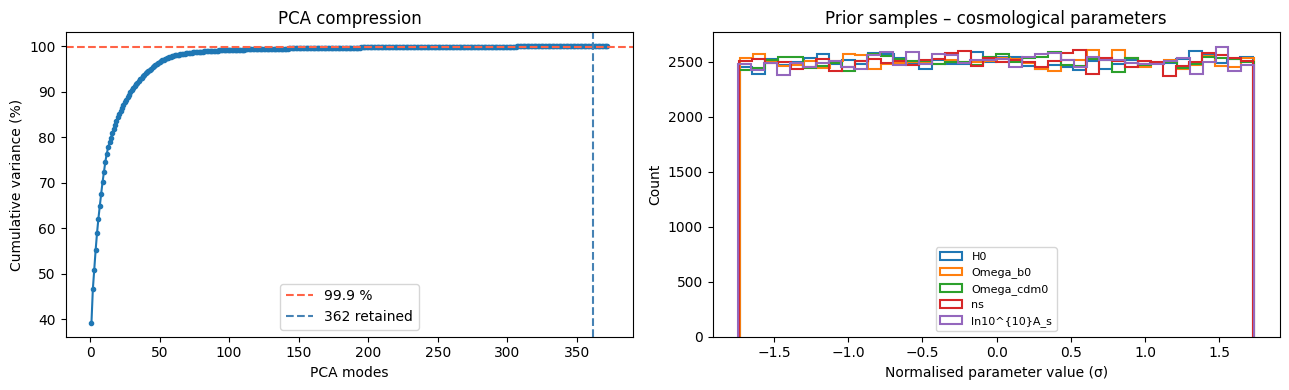

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from merlin_module.params import COSMO_PARAMS, N_COSMO

Cells_chol = store_samples['C_ells'].numpy() if hasattr(store_samples['C_ells'], 'numpy') else np.array(store_samples['C_ells'])

# ── PCA cumulative variance ────────────────────────────────────────────────
n_ret  = V_proj.shape[1]
fCells = torch.from_numpy(Cells_chol.reshape(len(store["z"]), -1))
q_viz  = min(n_ret + 10, fCells.shape[1])   # defined AFTER fCells

_, S, _ = torch.pca_lowrank(fCells, q=q_viz, center=True)
cumvar  = (S.cumsum(0) / S.sum()).numpy() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(np.arange(1, len(cumvar) + 1), cumvar, marker="o", ms=3)
axes[0].axhline(99.9, color="tomato", ls="--", label="99.9 %")
axes[0].axvline(n_ret, color="steelblue", ls="--", label=f"{n_ret} retained")
axes[0].set_xlabel("PCA modes")
axes[0].set_ylabel("Cumulative variance (%)")
axes[0].set_title("PCA compression")
axes[0].legend()

# ── Cosmological parameter priors (normalised so all are visible) ──────────
z_np   = store["z"][:, :N_COSMO]
z_norm = (z_np - z_np.mean(axis=0)) / z_np.std(axis=0)

for i, name in enumerate(COSMO_PARAMS):
    axes[1].hist(z_norm[:, i], bins=40, label=name, histtype="step", lw=1.5)


axes[1].set_xlabel("Normalised parameter value (σ)")
axes[1].set_ylabel("Count")
axes[1].set_title("Prior samples – cosmological parameters")
axes[1].legend(fontsize=8)

print(f"Retained {n_ret} modes → {cumvar[n_ret - 1]:.3f} % variance")

plt.tight_layout()
plt.show()

# Load the simulator 

In [45]:
sim = merlin.build_simulator(config)

ell_theory = np.load(config["AUX FILES"]["ell_file"])
print(f"n_bins        = {sim.n_bins}")
print(f"n_data        = {sim.n_data}  (WL + GGL + GCph combined)")
print(f"WL  spectra   = {len(sim.WL_keys)}")
print(f"GGL spectra   = {len(sim.GGL_keys)}")
print(f"GCph spectra  = {len(sim.GG_keys)}")
print(f"ell range     = [{ell_theory.min():.0f}, {ell_theory.max():.0f}]  ({len(ell_theory)} bins)")

n_bins        = 13
n_data        = 11232  (WL + GGL + GCph combined)
WL  spectra   = 91
GGL spectra   = 169
GCph spectra  = 91
ell range     = [11, 2755]  (32 bins)


Cosmological parameter names: ['H0', 'Omega_b0', 'Omega_cdm0', 'ns', 'ln10^{10}A_s']

5 prior draws (cosmo only):
[[6.59384e+01 5.01000e-02 2.76100e-01 9.51000e-01 3.07810e+00]
 [6.87260e+01 4.82000e-02 2.66100e-01 9.62100e-01 3.05430e+00]
 [6.42744e+01 4.90000e-02 2.64500e-01 9.60800e-01 3.08680e+00]
 [6.74596e+01 4.82000e-02 2.70100e-01 9.58200e-01 3.04960e+00]
 [6.62067e+01 5.14000e-02 2.71600e-01 9.65400e-01 3.08620e+00]]


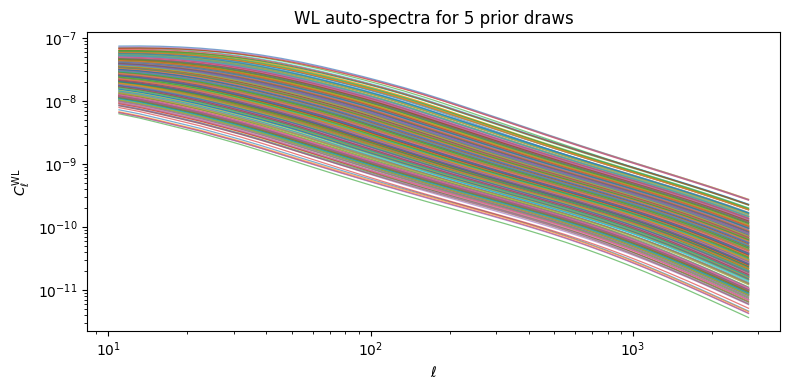

In [47]:

N_test = 5
z_samples = sim.sample_z(shape=(N_test,))   # (N_test, N_params)

print("Cosmological parameter names:", COSMO_PARAMS)
print(f"\n{N_test} prior draws (cosmo only):")
print(z_samples[:, :N_COSMO].round(4))

fig, ax = plt.subplots(figsize=(8, 4))
for z in z_samples:
    cls = sim.get_sample_Cls(z)
    n_wl = len(sim.WL_keys)
    wl_cls = cls[:n_wl * len(ell_theory)].reshape(n_wl, len(ell_theory))
    ax.plot(ell_theory, wl_cls.T, lw=0.9, alpha=0.6)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$\ell$")
ax.set_ylabel(r"$C_\ell^{\rm WL}$")
ax.set_title(f"WL auto-spectra for {N_test} prior draws")
plt.tight_layout()
plt.show()

# Train

In [12]:
config['INFERENCE']['params']= 'COSMO'

In [ ]:
network, trainer = merlin.train(store_samples, V_proj, config, num_workers=0)

/gpfs/home5/awernersson/venvs/cloe2/lib64/python3.11/site-packages/lightning_fabric/plugins/environments/slurm.py:165: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /gpfs/home5/awernersson/venvs/cloe2/lib64/python3.11 ...
  rank_zero_warn(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/gpfs/home5/awernersson/venvs/cloe2/lib64/python3.11/site-packages/lightning_fabric/plugins/environments/slurm.py:165: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /gpfs/home5/awernersson/venvs/cloe2/lib64/python3.11 ...
  rank_zero_warn(
The following callbacks returned in `LightningModule.configu

Sanity Checking: 0it [00:00, ?it/s]

/gpfs/home5/awernersson/venvs/cloe2/lib64/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:224: PossibleUserWarning: The dataloader, val_dataloader 0, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 72 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
/gpfs/home5/awernersson/venvs/cloe2/lib64/python3.11/site-packages/torch/__init__.py:1275: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at /pytorch/torch/csrc/tensor/python_tensor.cpp:434.)
  _C._set_default_tensor_type(t)
/gpfs/home5/awernersson/venvs/cloe2/lib64/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:224: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may b

Training: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

...

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Reloading best model: /gpfs/home5/awernersson/projects/merlin_module/lightning_logs/version_23057438/checkpoints/epoch=27-step=8764.ckpt


In [18]:
obs = np.load(config["OBSERVATION"]["OBS_CHOLESKY_NOISELESS"], allow_pickle=True).item()
obs_sample = swyft.Sample(obs)

In [14]:
obs  = np.load(config["OBSERVATION"]["OBS_CHOLESKY_NOISELESS"], allow_pickle=True).item()
mask = merlin.make_scale_cut_mask(config)
obs_sample = swyft.Sample({'C_ells': obs['C_ells'] * mask, 'noise': obs['noise']})


Scale cuts: 8788/11232 data points retained (WL ℓ≤1500, GGL ℓ≤750, GCph ℓ≤750)


In [21]:
obs  = np.load(config["OBSERVATION"]["OBS"], allow_pickle=True).item()
Lfid = np.load(config["OBSERVATION"]["LFID"])
obs_sample = merlin.data.preprocess_obs(obs, Lfid, config=config)


Scale cuts: 8788/11232 data points retained (WL ℓ≤1500, GGL ℓ≤750, GCph ℓ≤750)


In [22]:
config['STORES']['predictions_cosmo'] =  '/gpfs/scratch1/shared/awernersson/swyft_cloelib/predictions/merlin_cosmo_predictions_module22M_cutsmodule.npy'

predictions_cuts = merlin.infer(trainer, network, obs_sample, config)


/gpfs/home5/awernersson/venvs/cloe2/lib64/python3.11/site-packages/lightning_fabric/plugins/environments/slurm.py:165: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /gpfs/home5/awernersson/venvs/cloe2/lib64/python3.11 ...
  rank_zero_warn(
The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
You are using a CUDA device ('NVIDIA A100-SXM4-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 313it [00:00, ?it/s]

Predictions saved to /gpfs/scratch1/shared/awernersson/swyft_cloelib/predictions/merlin_cosmo_predictions_module22M_cutsmodule.npy


In [31]:
predictions = np.load('/gpfs/scratch1/shared/awernersson/swyft_cloelib/predictions/merlin_cosmo_predictions_module22M.npy', allow_pickle=True)

In [18]:
### Add MCMC
# ---- Load MCMC chain ----
from getdist import MCSamples
data    = np.load('/gpfs/scratch1/shared/awernersson/swyft_cloelib/MCMC/guada_chains.hdf5',
                  allow_pickle=True)
chain   = data['chain'].item()
weights = data['weights'] if 'weights' in data else np.ones(len(chain['H0']))
log_w   = weights - weights.max()
w_norm  = np.exp(log_w); w_norm /= w_norm.sum()

mcmc_keys = ['H0', 'Omega_b0', 'Omega_cdm0', 'ns', 'logAs']
chain_2d  = np.column_stack([chain[k] for k in mcmc_keys])
rng       = np.random.default_rng(42)
idx_mc    = rng.choice(len(chain_2d), size=50_000, replace=True, p=w_norm)
chain_r   = chain_2d[idx_mc]
samples = MCSamples(samples=chain_r, names=mcmc_keys)

Removed no burn in


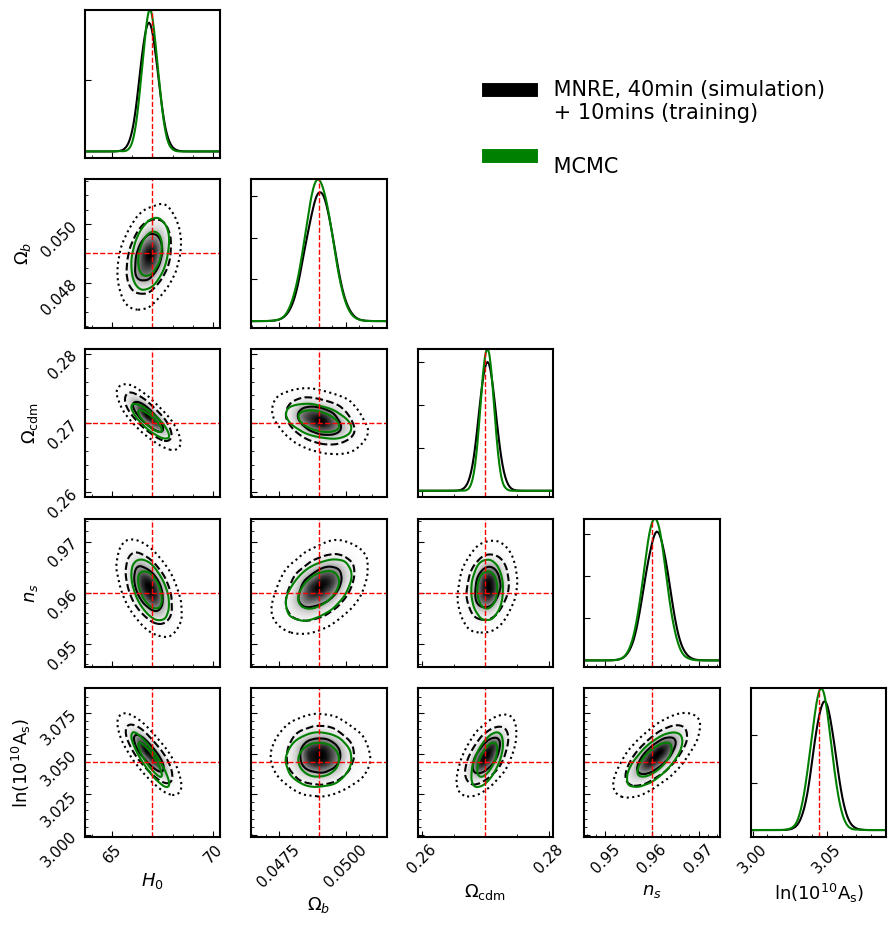

In [37]:
%matplotlib inline
from matplotlib.lines import Line2D

fiducial = list(config['FIDUCIAL VALUES'].values())

N_plot = network.num_params_show
fig, axes = plt.subplots(N_plot, N_plot, figsize=(9,9))
color_swyft='black'
color_mcmc='green'
color_fid = 'red'
fontsize_tick = 11

plot_pars = [r'$H_0$', r'$\Omega_b$', r'$\Omega_{\rm cdm}$', r'$n_s$', r'$\rm{ln}(10^{10}A_s)$']
swyft.plot_corner(predictions, ('z[0]', 'z[1]', 'z[2]','z[3]','z[4]'),
                  color=color_swyft, fig=fig, bins=100, smooth=2, contours_1d=False)

xlims = [axes[i, i].get_xlim() for i in range(N_plot)]
ylims_diag = [axes[i, i].get_ylim() for i in range(N_plot)]
ylims_off = {(j, i): axes[j, i].get_ylim() for i, j in network.marginals}
xlims_off = {(j, i): axes[j, i].get_xlim() for i, j in network.marginals}

for i in range(N_plot):
    density = samples.get1DDensity(mcmc_keys[i])
    xs = np.linspace(*xlims[i], 500)
    ys = density.Prob(xs)
    if ys.max() > 0:
        ys = ys / ys.max() * ylims_diag[i][1]
    axes[i, i].plot(xs, ys, color=color_mcmc, lw=1.5)
    axes[i, i].set_xlim(xlims[i])
    axes[i, i].set_ylim(ylims_diag[i])

for i, j in network.marginals:
    density2d = samples.get2DDensity(mcmc_keys[i], mcmc_keys[j], normalized=True)
    xs = np.linspace(*xlims_off[(j, i)], 200)
    ys = np.linspace(*ylims_off[(j, i)], 200)
    XX, YY = np.meshgrid(xs, ys)
    ZZ = density2d.Prob(XX, YY)
    levels = sorted(density2d.getContourLevels([0.68, 0.95]))
    axes[j, i].contour(XX, YY, ZZ, levels=levels, colors=color_mcmc, linewidths=1.5)
    axes[j, i].set_xlim(xlims_off[(j, i)])
    axes[j, i].set_ylim(ylims_off[(j, i)])

for i in range(N_plot):
    axes[i, i].axvline(fiducial[i], color=color_fid, lw=1., linestyle='dashed')
    axes[i, i].minorticks_on()
    axes[i, i].tick_params(axis='both', which='major', direction="in", labelsize=fontsize_tick, rotation=45, size=4)
    axes[i, i].tick_params(axis='both', which='minor', direction="in", labelsize=fontsize_tick, rotation=45, size=2, left=False)

for i, j in network.marginals:
    axes[j, i].axvline(fiducial[i], color=color_fid, lw=1., linestyle='dashed')
    axes[j, i].axhline(fiducial[j], color=color_fid, lw=1., linestyle='dashed')
    axes[j, i].minorticks_on()
    axes[j, i].tick_params(axis='both', which='major', direction="in", labelsize=fontsize_tick, rotation=45, size=4)
    axes[j, i].tick_params(axis='both', which='minor', direction="in", labelsize=fontsize_tick, rotation=45, size=2)

for i in range(N_plot):
    axes[N_plot-1, i].tick_params(axis='both', which='major', direction="in", labelsize=fontsize_tick, rotation=45, size=4)
    axes[N_plot-1, i].tick_params(axis='both', which='minor', direction="in", labelsize=fontsize_tick, rotation=45, size=2)
    axes[N_plot-1, i].set_xlabel(plot_pars[i], fontsize=13)
    axes[N_plot-1, i].minorticks_on()

for i in range(1, N_plot):
    axes[i, 0].set_ylabel(plot_pars[i], fontsize=13)
    axes[i, 0].tick_params(axis='both', which='major', direction="in", labelsize=fontsize_tick, size=4)
    axes[i, 0].tick_params(axis='both', which='minor', direction="in", labelsize=fontsize_tick, rotation=45, size=2)
    axes[i, 0].minorticks_on()

for i, j in network.marginals:
    [x.set_linewidth(1.5) for x in axes[j, i].spines.values()]
for i in range(N_plot):
    [x.set_linewidth(1.5) for x in axes[i, i].spines.values()]

labels = ['\n MNRE, 40min (simulation) \n + 10mins (training)', '\n MCMC']
colors = [color_swyft, color_mcmc]
lines = [Line2D([0], [0], color=c, linewidth=10, linestyle='-') for c in colors]
plt.legend(lines, labels, loc=(-2.0, 4.4), fontsize=15, frameon=False)

plt.show()


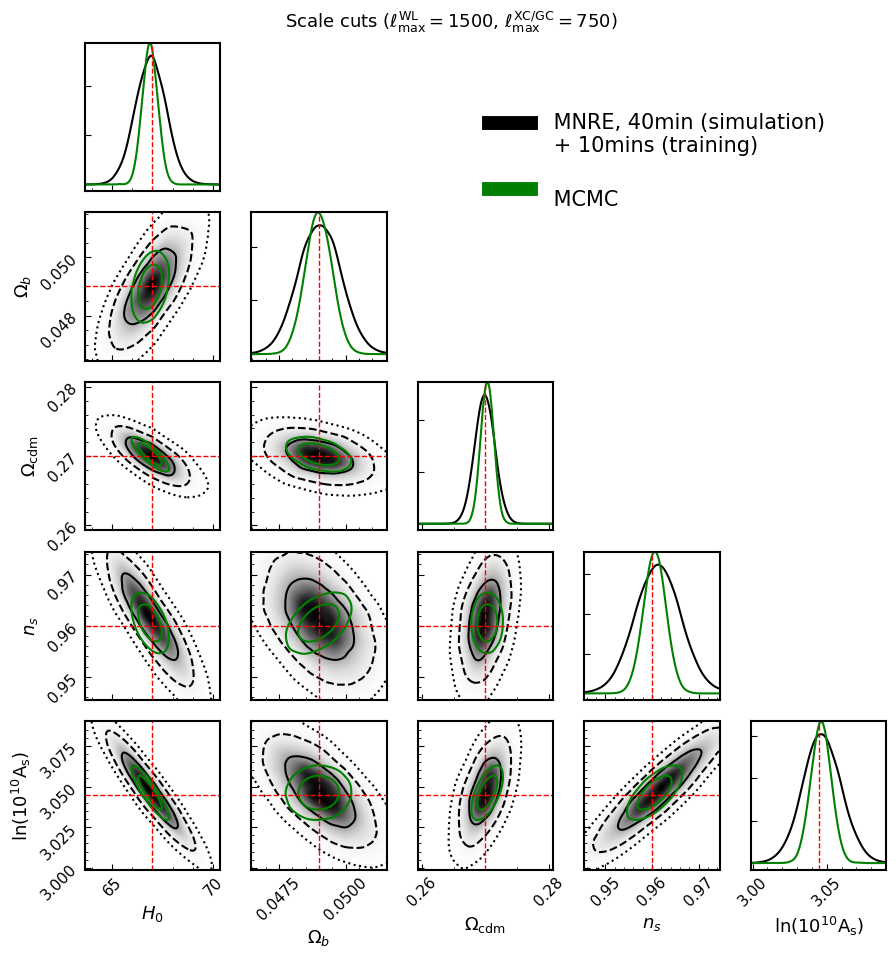

In [25]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fiducial = list(config['FIDUCIAL VALUES'].values())

N_plot = 5
fig, axes = plt.subplots(N_plot, N_plot, figsize=(9,9))
color_swyft='black'
color_mcmc='green'
color_fid = 'red'
fontsize_tick = 11

plot_pars = [r'$H_0$', r'$\Omega_b$', r'$\Omega_{\rm cdm}$', r'$n_s$', r'$\rm{ln}(10^{10}A_s)$']
swyft.plot_corner(predictions_cuts, ('z[0]', 'z[1]', 'z[2]','z[3]','z[4]'),
                  color=color_swyft, fig=fig, bins=100, smooth=2, contours_1d=False)

xlims = [axes[i, i].get_xlim() for i in range(N_plot)]
ylims_diag = [axes[i, i].get_ylim() for i in range(N_plot)]
ylims_off = {(j, i): axes[j, i].get_ylim() for i, j in network.marginals}
xlims_off = {(j, i): axes[j, i].get_xlim() for i, j in network.marginals}

for i in range(N_plot):
    density = samples.get1DDensity(mcmc_keys[i])
    xs = np.linspace(*xlims[i], 500)
    ys = density.Prob(xs)
    if ys.max() > 0:
        ys = ys / ys.max() * ylims_diag[i][1]
    axes[i, i].plot(xs, ys, color=color_mcmc, lw=1.5)
    axes[i, i].set_xlim(xlims[i])
    axes[i, i].set_ylim(ylims_diag[i])

for i, j in network.marginals:
    density2d = samples.get2DDensity(mcmc_keys[i], mcmc_keys[j], normalized=True)
    xs = np.linspace(*xlims_off[(j, i)], 200)
    ys = np.linspace(*ylims_off[(j, i)], 200)
    XX, YY = np.meshgrid(xs, ys)
    ZZ = density2d.Prob(XX, YY)
    levels = sorted(density2d.getContourLevels([0.68, 0.95]))
    axes[j, i].contour(XX, YY, ZZ, levels=levels, colors=color_mcmc, linewidths=1.5)
    axes[j, i].set_xlim(xlims_off[(j, i)])
    axes[j, i].set_ylim(ylims_off[(j, i)])

for i in range(N_plot):
    axes[i, i].axvline(fiducial[i], color=color_fid, lw=1., linestyle='dashed')
    axes[i, i].minorticks_on()
    axes[i, i].tick_params(axis='both', which='major', direction="in", labelsize=fontsize_tick, rotation=45, size=4)
    axes[i, i].tick_params(axis='both', which='minor', direction="in", labelsize=fontsize_tick, rotation=45, size=2, left=False)

for i, j in network.marginals:
    axes[j, i].axvline(fiducial[i], color=color_fid, lw=1., linestyle='dashed')
    axes[j, i].axhline(fiducial[j], color=color_fid, lw=1., linestyle='dashed')
    axes[j, i].minorticks_on()
    axes[j, i].tick_params(axis='both', which='major', direction="in", labelsize=fontsize_tick, rotation=45, size=4)
    axes[j, i].tick_params(axis='both', which='minor', direction="in", labelsize=fontsize_tick, rotation=45, size=2)

for i in range(N_plot):
    axes[N_plot-1, i].tick_params(axis='both', which='major', direction="in", labelsize=fontsize_tick, rotation=45, size=4)
    axes[N_plot-1, i].tick_params(axis='both', which='minor', direction="in", labelsize=fontsize_tick, rotation=45, size=2)
    axes[N_plot-1, i].set_xlabel(plot_pars[i], fontsize=13)
    axes[N_plot-1, i].minorticks_on()

for i in range(1, N_plot):
    axes[i, 0].set_ylabel(plot_pars[i], fontsize=13)
    axes[i, 0].tick_params(axis='both', which='major', direction="in", labelsize=fontsize_tick, size=4)
    axes[i, 0].tick_params(axis='both', which='minor', direction="in", labelsize=fontsize_tick, rotation=45, size=2)
    axes[i, 0].minorticks_on()

for i, j in network.marginals:
    [x.set_linewidth(1.5) for x in axes[j, i].spines.values()]
for i in range(N_plot):
    [x.set_linewidth(1.5) for x in axes[i, i].spines.values()]

labels = ['\n MNRE, 40min (simulation) \n + 10mins (training)', '\n MCMC']
colors = [color_swyft, color_mcmc]
lines = [Line2D([0], [0], color=c, linewidth=10, linestyle='-') for c in colors]
plt.legend(lines, labels, loc=(-2.0, 4.4), fontsize=15, frameon=False)
plt.suptitle(r'Scale cuts ($\ell_{\rm max}^{\rm WL}=1500$, $\ell_{\rm max}^{\rm XC/GC}=750$)',
             fontsize=13, y=1.02)
plt.savefig('scalecuts_cosmo_swyftcloelib.png')
plt.show()


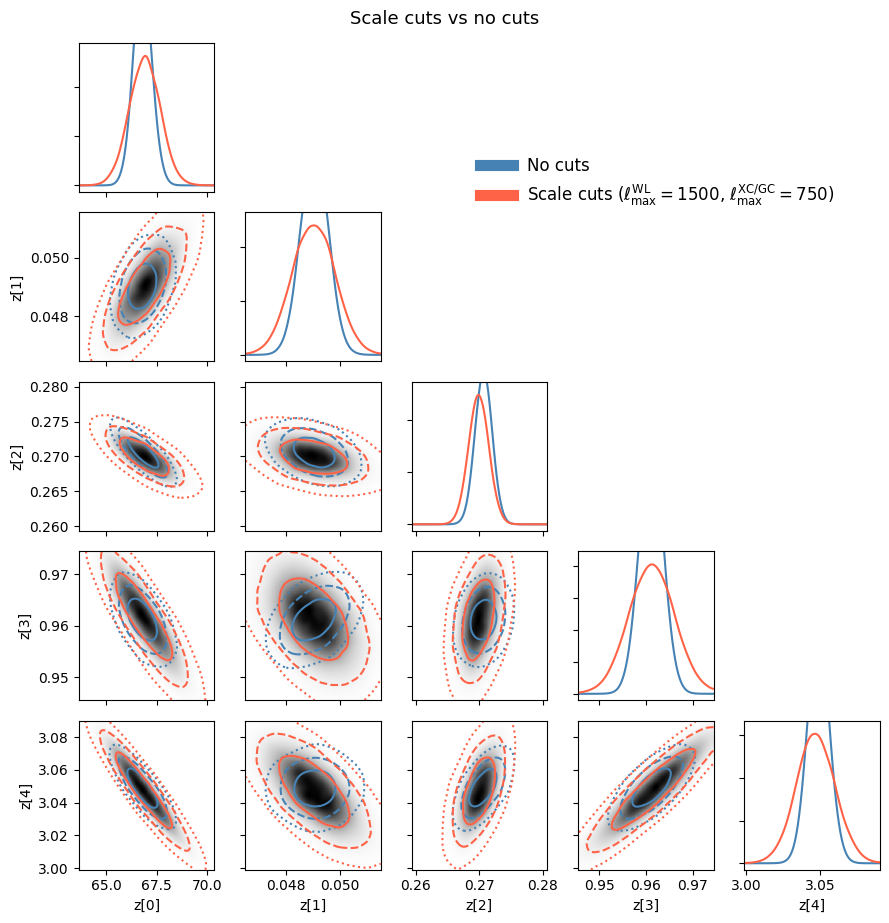

In [32]:
# ── Overlay: no cuts vs scale cuts ───────────────────────────────────────
fig, axes = plt.subplots(N_plot, N_plot, figsize=(9, 9))

swyft.plot_corner(predictions,      ('z[0]','z[1]','z[2]','z[3]','z[4]'),
                  color='steelblue', fig=fig, bins=100, smooth=2, contours_1d=False)
swyft.plot_corner(predictions_cuts, ('z[0]','z[1]','z[2]','z[3]','z[4]'),
                  color='tomato',    fig=fig, bins=100, smooth=2, contours_1d=False)

labels = ['No cuts', r'Scale cuts ($\ell_{\rm max}^{\rm WL}=1500$, $\ell_{\rm max}^{\rm XC/GC}=750$)']
lines  = [Line2D([0],[0], color=c, linewidth=8) for c in ['steelblue','tomato']]
plt.legend(lines, labels, loc=(-2.0, 4.4), fontsize=12, frameon=False)
plt.suptitle('Scale cuts vs no cuts', fontsize=13, y=1.02)
plt.show()


# Do coverage test

In [26]:
from scipy import stats

fiducial = list(config['FIDUCIAL VALUES'].values())

sigmas, lower_bounds, upper_bounds = merlin.get_sigmas_bounds(
    fiducial,
    config['FINV']['finv_file'],
    network.num_params_show   
)

lower = np.array(lower_bounds)
width = np.array(upper_bounds) - np.array(lower_bounds)

prior_samples_2 = swyft.Samples(
    z=stats.uniform(lower, width).rvs(size=(10_000, network.num_params_show))
)


In [27]:
# we use last 500 samples from the store
coverage_samples = trainer.test_coverage(network, store_samples[-500:], prior_samples_2) 

/gpfs/home5/awernersson/venvs/cloe2/lib64/python3.11/site-packages/lightning_fabric/plugins/environments/slurm.py:165: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /gpfs/home5/awernersson/venvs/cloe2/lib64/python3.11 ...
  rank_zero_warn(
The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
You are using a CUDA device ('NVIDIA A100-SXM4-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 313it [00:00, ?it/s]

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
You are using a CUDA device ('NVIDIA A100-SXM4-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 313it [00:00, ?it/s]

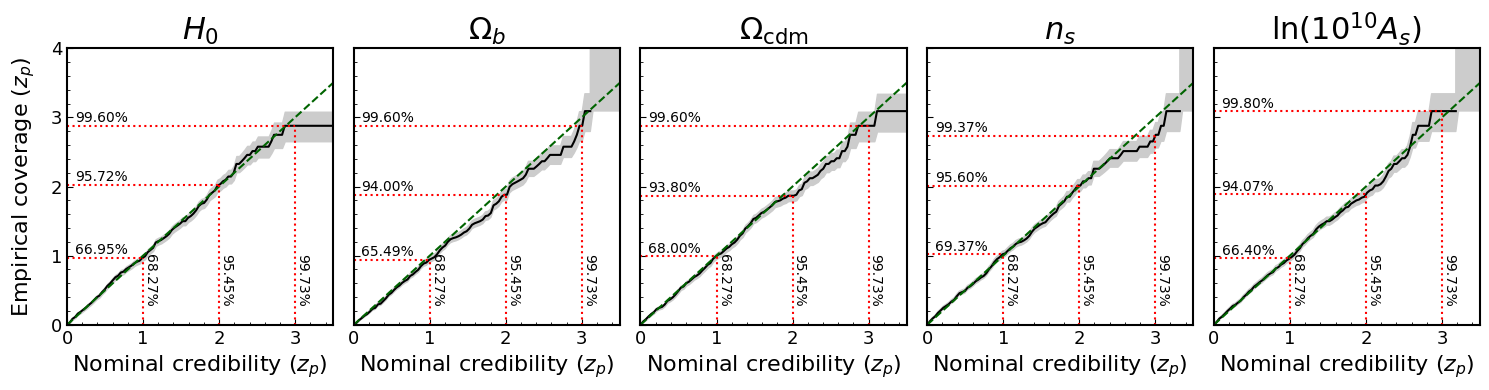

In [50]:
%matplotlib inline

N_plot = 5
fig, axes = plt.subplots(1, 5, figsize = (15, 4))
    
for i in range(5):
    swyft.plot_zz(coverage_samples, "z[%i]"%i, ax = axes[i],bins=100)
    
fontsize_title = 22
axes[0].set_title(r'$H_0$',fontsize =fontsize_title)
axes[1].set_title(r'$\Omega_b$',fontsize =fontsize_title)
axes[2].set_title(r'$\Omega_{\mathrm{cdm}}$',fontsize =fontsize_title)
axes[3].set_title(r'$n_s$',fontsize =fontsize_title)
axes[4].set_title(r'$\mathrm{ln}(10^{10}A_s)$',fontsize =fontsize_title)

for i in range(1,N_plot):
    axes[i].set_ylabel(None)
    axes[i].set_yticklabels([]) 

fontsize_labels=16
for i in range(N_plot):
    axes[i].set_xlabel(r'Nominal credibility ($z_p$)',fontsize=fontsize_labels)

axes[0].set_ylabel(r'Empirical coverage ($z_p$)',fontsize=fontsize_labels,labelpad=10)
    
fontsize_tick=13
for i in range(N_plot):
    [x.set_linewidth(1.5) for x in axes[i].spines.values()]
    axes[i].minorticks_on()
    axes[i].tick_params(axis='both', which='major',direction="in", labelsize=fontsize_tick,size=4)
    axes[i].tick_params(axis='both', which='minor',direction="in", labelsize=fontsize_tick,size=2)
    axes[i].yaxis.set_major_locator(plt.MaxNLocator(4))

plt.tight_layout()
# save figure
#plt.savefig('coverage_cosmo_swyft_cloelib.pdf')

plt.show()

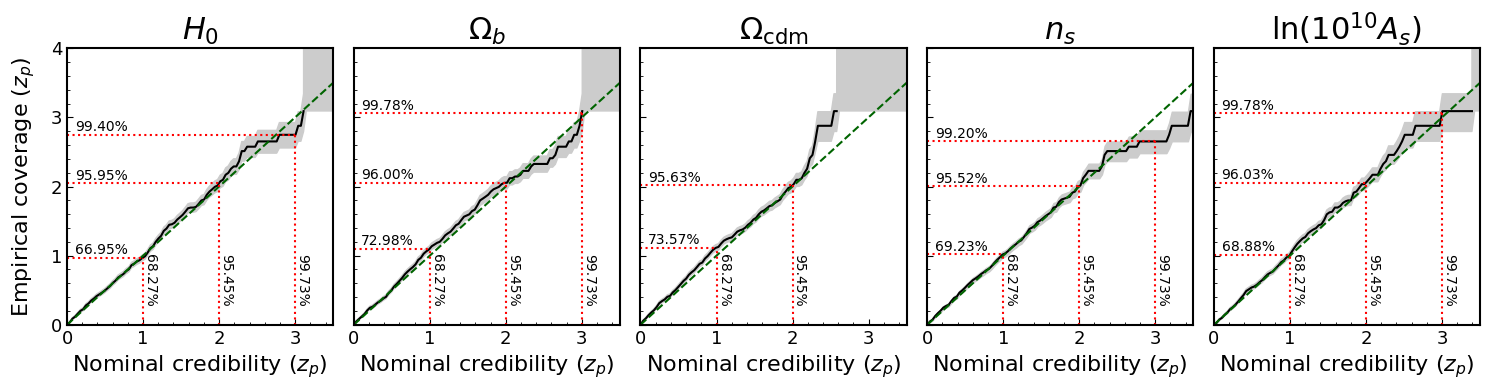

In [28]:
%matplotlib inline

N_plot = 5
fig, axes = plt.subplots(1, 5, figsize = (15, 4))
    
for i in range(5):
    swyft.plot_zz(coverage_samples, "z[%i]"%i, ax = axes[i],bins=100)
    
fontsize_title = 22
axes[0].set_title(r'$H_0$',fontsize =fontsize_title)
axes[1].set_title(r'$\Omega_b$',fontsize =fontsize_title)
axes[2].set_title(r'$\Omega_{\mathrm{cdm}}$',fontsize =fontsize_title)
axes[3].set_title(r'$n_s$',fontsize =fontsize_title)
axes[4].set_title(r'$\mathrm{ln}(10^{10}A_s)$',fontsize =fontsize_title)

for i in range(1,N_plot):
    axes[i].set_ylabel(None)
    axes[i].set_yticklabels([]) 

fontsize_labels=16
for i in range(N_plot):
    axes[i].set_xlabel(r'Nominal credibility ($z_p$)',fontsize=fontsize_labels)

axes[0].set_ylabel(r'Empirical coverage ($z_p$)',fontsize=fontsize_labels,labelpad=10)
    
fontsize_tick=13
for i in range(N_plot):
    [x.set_linewidth(1.5) for x in axes[i].spines.values()]
    axes[i].minorticks_on()
    axes[i].tick_params(axis='both', which='major',direction="in", labelsize=fontsize_tick,size=4)
    axes[i].tick_params(axis='both', which='minor',direction="in", labelsize=fontsize_tick,size=2)
    axes[i].yaxis.set_major_locator(plt.MaxNLocator(4))

plt.tight_layout()
# save figure
plt.savefig('coverage_cosmo_swyft_cloelib_scalecuts.pdf')

plt.show()